First 5 rows:
             State   Crop  CostCultivation  CostCultivation2  Production  \
0   Uttar Pradesh  ARHAR          9794.05           9800.25     1941.55   
1       Karnataka  ARHAR         10593.15          10594.15     2172.46   
2         Gujarat  ARHAR         13468.82          13469.82     1898.30   
3  Andhra Pradesh  ARHAR         17051.66          17052.66     3670.54   
4     Maharashtra  ARHAR         17130.55          17131.55     2775.80   

   Yield  Temperature  RainFall Annual     Price  
0   9.83        28.96           3373.2  19589.10  
1   7.47        29.22           3520.7  21187.30  
2   9.59        28.47           2957.4  26938.64  
3   6.42        28.49           3079.6  34104.32  
4   8.72        28.30           2566.7  34262.10  

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   State      

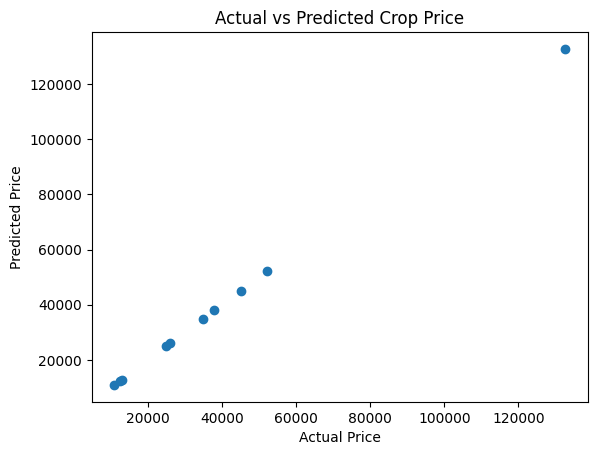


Feature Importance:
                    Coefficient
State             5.031779e-13
Crop             -1.484146e-12
CostCultivation   2.000000e+00
CostCultivation2 -7.408518e-13
Production        1.082467e-15
Yield             1.136938e-14
Temperature       1.130315e-12
RainFall Annual   1.819725e-15


In [1]:
# ==============================
# 1. Import Libraries
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# ==============================
# 2. Load Dataset
# ==============================
df = pd.read_csv('/content/dataset (1) .csv')

print("First 5 rows:\n", df.head())
print("\nDataset Info:\n")
print(df.info())

# ==============================
# 3. Handle Missing Values
# ==============================
print("\nMissing Values:\n", df.isnull().sum())

# Fill numeric missing values with mean
df.fillna(df.mean(numeric_only=True), inplace=True)

# ==============================
# 4. Encode Categorical Columns
# ==============================
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# ==============================
# 5. Define Features & Target
# ==============================
X = df.drop('Price', axis=1)   # Features
y = df['Price']                # Target

# ==============================
# 6. Train-Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 7. Train Model
# ==============================
model = LinearRegression()
model.fit(X_train, y_train)

# ==============================
# 8. Prediction
# ==============================
y_pred = model.predict(X_test)

# ==============================
# 9. Evaluation
# ==============================
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

# ==============================
# 10. Visualization
# ==============================
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Crop Price")
plt.show()

# ==============================
# 11. Feature Importance
# ==============================
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print("\nFeature Importance:\n", coeff_df)